# Multiclass Classification: Student Outcomes Prediction
## Predicting Student Status (Dropout, Enrolled, Graduate)

This notebook builds and evaluates 9 machine learning models across 3 feature sets to predict student outcomes.

## 1. Import Required Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Data

In [13]:
# Load data
df = pd.read_csv('data.csv', sep=';')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nColumn Names (first 15):")
print(df.columns[:15].tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['Target'].value_counts())
print("\nTarget Proportions:")
print(df['Target'].value_counts(normalize=True))

Dataset Shape: (4424, 37)

First few rows:
   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1           

## 3. Create Feature Sets

In [14]:
# Define feature categories based on column names

# Demographic features (df_early)
demographic_features = [
    'Marital status', 'Application mode', 'Application order', 'Course', 
    'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)',
    'Nacionality', "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation", 'Admission grade',
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# 1st semester features
sem1_features = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)'
]

# 2nd semester features
sem2_features = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]

# Verify feature availability
available_cols = set(df.columns)
demographic_features = [f for f in demographic_features if f in available_cols]
sem1_features = [f for f in sem1_features if f in available_cols]
sem2_features = [f for f in sem2_features if f in available_cols]

print(f"Demographic features: {len(demographic_features)}")
print(f"1st semester features: {len(sem1_features)}")
print(f"2nd semester features: {len(sem2_features)}")

# Create feature sets
df_early = df[demographic_features + ['Target']].copy()
df_mid = df[demographic_features + sem1_features + ['Target']].copy()
df_full = df[demographic_features + sem1_features + sem2_features + ['Target']].copy()

print(f"\ndf_early shape: {df_early.shape}")
print(f"df_mid shape: {df_mid.shape}")
print(f"df_full shape: {df_full.shape}")

Demographic features: 24
1st semester features: 6
2nd semester features: 6

df_early shape: (4424, 25)
df_mid shape: (4424, 31)
df_full shape: (4424, 37)


## Preprocessing: Encode Categorical Variables and Handle Missing Values

In [17]:
def preprocess_data(df):
    """
    Preprocess data: encode categorical variables and handle missing values
    """
    df_processed = df.copy()
    
    # Separate target
    target = df_processed['Target']
    X = df_processed.drop('Target', axis=1)
    
    # Fill missing values with median for numerical columns
    for col in X.columns:
        if X[col].dtype != 'object':
            X[col].fillna(X[col].median(), inplace=True)
        else:
            X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'Unknown', inplace=True)
    
    # Encode categorical variables
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
    
    # Encode target variable
    le_target = LabelEncoder()
    target = le_target.fit_transform(target)
    label_encoders['Target'] = le_target
    
    return X, target, label_encoders

# Preprocess all three datasets
X_early, y, label_encoders_early = preprocess_data(df_early)
X_mid, _, label_encoders_mid = preprocess_data(df_mid)
X_full, _, label_encoders_full = preprocess_data(df_full)

# Store target encoder for reference
le_target = label_encoders_early.get('Target')

print("Data preprocessing completed!")
print(f"X_early shape: {X_early.shape}")
print(f"X_mid shape: {X_mid.shape}")
print(f"X_full shape: {X_full.shape}")
print(f"\nTarget numeric distribution: {dict(zip(np.unique(y), np.bincount(y)))}")
print(f"Target labels mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

Data preprocessing completed!
X_early shape: (4424, 24)
X_mid shape: (4424, 30)
X_full shape: (4424, 36)

Target numeric distribution: {np.int64(0): np.int64(1421), np.int64(1): np.int64(794), np.int64(2): np.int64(2209)}
Target labels mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


## 4. Model Setup Explanation

### Why This Model Setup?

#### 1. **Three Feature Sets (Progressive Complexity)**
- **df_early**: Only demographic data available at enrollment. Shows baseline prediction capability without behavioral data.
- **df_mid**: Adds 1st semester performance. Early intervention point - can identify students at risk before 2nd semester.
- **df_full**: Includes both semesters. Most complete picture for end-of-year prediction.

This design allows us to:
- Quantify the value of semester performance data
- Identify the optimal data collection point for intervention
- Understand how model performance improves with richer features

#### 2. **Three Algorithms (Interpretability vs. Performance Trade-off)**

**a) Multinomial Logistic Regression (Ridge/Lasso Regularization) - Baseline**
- Linear model, highly interpretable
- Ridge (L2): Shrinks all coefficients toward zero proportionally (better for correlated features)
- Lasso (L1): Can shrink some coefficients to exactly zero (automatic feature selection)
- Provides baseline performance and feature importance insights

**b) Random Forest - Ensemble Tree-Based**
- Handles non-linear relationships and feature interactions well
- Robust to outliers, less prone to overfitting
- Provides feature importance rankings
- No feature scaling required

**c) XGBoost - Advanced Gradient Boosting**
- State-of-the-art gradient boosting, often achieves best performance
- Captures complex patterns in data
- Handles class imbalance through scale_pos_weight and regularization
- Computationally expensive but powerful

**Total Models: 3 Datasets × 3 Algorithms = 9 Models**
- Enables systematic analysis of performance trade-offs
- Shows which algorithm benefits most from additional features

## 5. Split Data into Train and Test Sets

In [18]:
# Stratified split to maintain class distribution
X_early_train, X_early_test, y_train, y_test = train_test_split(
    X_early, y, test_size=0.2, random_state=42, stratify=y
)

X_mid_train, X_mid_test, y_train_mid, y_test_mid = train_test_split(
    X_mid, y, test_size=0.2, random_state=42, stratify=y
)

X_full_train, X_full_test, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for logistic regression
scaler_early = StandardScaler()
X_early_train_scaled = scaler_early.fit_transform(X_early_train)
X_early_test_scaled = scaler_early.transform(X_early_test)

scaler_mid = StandardScaler()
X_mid_train_scaled = scaler_mid.fit_transform(X_mid_train)
X_mid_test_scaled = scaler_mid.transform(X_mid_test)

scaler_full = StandardScaler()
X_full_train_scaled = scaler_full.fit_transform(X_full_train)
X_full_test_scaled = scaler_full.transform(X_full_test)

print("Data split completed!")
print(f"\nTrain size: {len(X_early_train)} | Test size: {len(X_early_test)}")
print(f"Train-Test Ratio: 80-20")
print(f"\nClass distribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique_train, counts_train):
    print(f"  Class {cls}: {cnt}")
print(f"\nClass distribution in test set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_test, counts_test):
    print(f"  Class {cls}: {cnt}")

Data split completed!

Train size: 3539 | Test size: 885
Train-Test Ratio: 80-20

Class distribution in training set:
  Class 0: 1137
  Class 1: 635
  Class 2: 1767

Class distribution in test set:
  Class 0: 284
  Class 1: 159
  Class 2: 442


## 6. Define and Train Baseline Models (Multinomial Logistic Regression)

In [19]:
# Store training and test data for each dataset
datasets = {
    'early': {
        'X_train': X_early_train_scaled, 'X_test': X_early_test_scaled,
        'y_train': y_train, 'y_test': y_test
    },
    'mid': {
        'X_train': X_mid_train_scaled, 'X_test': X_mid_test_scaled,
        'y_train': y_train, 'y_test': y_test
    },
    'full': {
        'X_train': X_full_train_scaled, 'X_test': X_full_test_scaled,
        'y_train': y_train, 'y_test': y_test
    }
}

# Dictionary to store all models
models = {}

# Train Multinomial Logistic Regression models
print("Training Multinomial Logistic Regression models...\n")

for dataset_name, dataset in datasets.items():
    # Ridge regularization
    model_ridge = LogisticRegression(
        multi_class='multinomial', penalty='l2', max_iter=1000,
        random_state=42, solver='lbfgs', C=1.0
    )
    model_ridge.fit(dataset['X_train'], dataset['y_train'])
    models[f'LogReg_Ridge_{dataset_name}'] = model_ridge
    print(f"✓ Trained LogReg_Ridge_{dataset_name}")
    
    # Lasso regularization (using saga solver which supports L1)
    model_lasso = LogisticRegression(
        multi_class='multinomial', penalty='l1', max_iter=1000,
        random_state=42, solver='saga', C=1.0
    )
    model_lasso.fit(dataset['X_train'], dataset['y_train'])
    models[f'LogReg_Lasso_{dataset_name}'] = model_lasso
    print(f"✓ Trained LogReg_Lasso_{dataset_name}")

print("\nBaseline models training completed!")

Training Multinomial Logistic Regression models...

✓ Trained LogReg_Ridge_early
✓ Trained LogReg_Lasso_early
✓ Trained LogReg_Ridge_mid
✓ Trained LogReg_Lasso_mid
✓ Trained LogReg_Ridge_full
✓ Trained LogReg_Lasso_full

Baseline models training completed!


## 7. Define and Train Random Forest Models

In [20]:
# Train Random Forest models
print("Training Random Forest models...\n")

# Use unscaled data for tree-based models
datasets_unscaled = {
    'early': {
        'X_train': X_early_train, 'X_test': X_early_test,
        'y_train': y_train, 'y_test': y_test
    },
    'mid': {
        'X_train': X_mid_train, 'X_test': X_mid_test,
        'y_train': y_train, 'y_test': y_test
    },
    'full': {
        'X_train': X_full_train, 'X_test': X_full_test,
        'y_train': y_train, 'y_test': y_test
    }
}

for dataset_name, dataset in datasets_unscaled.items():
    model_rf = RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42,
        n_jobs=-1, class_weight='balanced'
    )
    model_rf.fit(dataset['X_train'], dataset['y_train'])
    models[f'RandomForest_{dataset_name}'] = model_rf
    print(f"✓ Trained RandomForest_{dataset_name}")

print("\nRandom Forest models training completed!")

Training Random Forest models...

✓ Trained RandomForest_early
✓ Trained RandomForest_mid
✓ Trained RandomForest_full

Random Forest models training completed!


## 8. Define and Train XGBoost Models

In [21]:
# Training XGBoost models
print("Training XGBoost models...\n")

for dataset_name, dataset in datasets_unscaled.items():
    model_xgb = xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        max_depth=7, learning_rate=0.1, n_estimators=100,
        random_state=42, n_jobs=-1, verbosity=0,
        scale_pos_weight=1, eval_metric='mlogloss'
    )
    model_xgb.fit(dataset['X_train'], dataset['y_train'])
    models[f'XGBoost_{dataset_name}'] = model_xgb
    print(f"✓ Trained XGBoost_{dataset_name}")

print("\nXGBoost models training completed!")
print(f"\nTotal models trained: {len(models)}")

Training XGBoost models...

✓ Trained XGBoost_early
✓ Trained XGBoost_mid
✓ Trained XGBoost_full

XGBoost models training completed!

Total models trained: 12


## 9. Perform 5-Fold Cross-Validation

In [22]:
print("Performing 5-Fold Cross-Validation...\n")
print("="*80)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV for Logistic Regression models (using scaled data)
model_names_logit = [name for name in models.keys() if 'LogReg' in name]
for model_name in model_names_logit:
    dataset_name = model_name.split('_')[-1]
    X_train = datasets[dataset_name]['X_train']
    
    cv_scores = cross_val_score(
        models[model_name], X_train, y_train, cv=skf, scoring='f1_weighted'
    )
    cv_results[model_name] = {'mean': cv_scores.mean(), 'std': cv_scores.std()}
    print(f"{model_name:30s} | F1 (5-CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print()

# CV for tree-based models (using unscaled data)
model_names_tree = [name for name in models.keys() if 'RandomForest' in name or 'XGBoost' in name]
for model_name in model_names_tree:
    dataset_name = model_name.split('_')[-1]
    X_train = datasets_unscaled[dataset_name]['X_train']
    
    cv_scores = cross_val_score(
        models[model_name], X_train, y_train, cv=skf, scoring='f1_weighted'
    )
    cv_results[model_name] = {'mean': cv_scores.mean(), 'std': cv_scores.std()}
    print(f"{model_name:30s} | F1 (5-CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n" + "="*80)
print("Cross-Validation completed!")

Performing 5-Fold Cross-Validation...

LogReg_Ridge_early             | F1 (5-CV): 0.5739 (+/- 0.0108)
LogReg_Lasso_early             | F1 (5-CV): 0.5711 (+/- 0.0102)
LogReg_Ridge_mid               | F1 (5-CV): 0.7024 (+/- 0.0089)
LogReg_Lasso_mid               | F1 (5-CV): 0.7027 (+/- 0.0097)
LogReg_Ridge_full              | F1 (5-CV): 0.7484 (+/- 0.0138)
LogReg_Lasso_full              | F1 (5-CV): 0.7487 (+/- 0.0121)

RandomForest_early             | F1 (5-CV): 0.6134 (+/- 0.0078)
RandomForest_mid               | F1 (5-CV): 0.7316 (+/- 0.0140)
RandomForest_full              | F1 (5-CV): 0.7649 (+/- 0.0100)
XGBoost_early                  | F1 (5-CV): 0.6295 (+/- 0.0098)
XGBoost_mid                    | F1 (5-CV): 0.7380 (+/- 0.0096)
XGBoost_full                   | F1 (5-CV): 0.7643 (+/- 0.0067)

Cross-Validation completed!


## 10. Evaluate Models with F1, Accuracy, and ROC-AUC

In [23]:
def calculate_roc_auc_multiclass(y_true, y_pred_proba, labels):
    """
    Calculate ROC-AUC for multiclass using One-vs-Rest approach
    """
    if len(np.unique(y_true)) < len(labels):
        return np.nan  # Return NaN if we don't have all classes
    
    # Binarize the output
    y_bin = label_binarize(y_true, classes=labels)
    
    # Calculate ROC AUC for each class and average
    roc_auc_list = []
    for i, label in enumerate(labels):
        try:
            auc = roc_auc_score(y_bin[:, i], y_pred_proba[:, i])
            roc_auc_list.append(auc)
        except:
            pass
    
    return np.mean(roc_auc_list) if roc_auc_list else np.nan

print("Evaluating Models on Test Set...\n")
print("="*100)

evaluation_results = {}

# Evaluate Logistic Regression models
for model_name in model_names_logit:
    dataset_name = model_name.split('_')[-1]
    X_test = datasets[dataset_name]['X_test']
    y_test_current = datasets[dataset_name]['y_test']
    
    model = models[model_name]
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    f1 = f1_score(y_test_current, y_pred, average='weighted')
    accuracy = accuracy_score(y_test_current, y_pred)
    
    labels = model.classes_
    roc_auc = calculate_roc_auc_multiclass(y_test_current, y_pred_proba, labels)
    
    evaluation_results[model_name] = {
        'F1': f1, 'Accuracy': accuracy, 'ROC-AUC': roc_auc,
        'y_pred': y_pred
    }
    print(f"{model_name:30s} | F1: {f1:.4f} | Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f}")

print()

# Evaluate tree-based models
for model_name in model_names_tree:
    dataset_name = model_name.split('_')[-1]
    X_test = datasets_unscaled[dataset_name]['X_test']
    y_test_current = datasets_unscaled[dataset_name]['y_test']
    
    model = models[model_name]
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    f1 = f1_score(y_test_current, y_pred, average='weighted')
    accuracy = accuracy_score(y_test_current, y_pred)
    
    labels = model.classes_
    roc_auc = calculate_roc_auc_multiclass(y_test_current, y_pred_proba, labels)
    
    evaluation_results[model_name] = {
        'F1': f1, 'Accuracy': accuracy, 'ROC-AUC': roc_auc,
        'y_pred': y_pred
    }
    print(f"{model_name:30s} | F1: {f1:.4f} | Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f}")

print("\n" + "="*100)
print("Test Set Evaluation completed!")

Evaluating Models on Test Set...

LogReg_Ridge_early             | F1: 0.5744 | Accuracy: 0.6249 | ROC-AUC: 0.7278
LogReg_Lasso_early             | F1: 0.5747 | Accuracy: 0.6249 | ROC-AUC: 0.7280
LogReg_Ridge_mid               | F1: 0.7032 | Accuracy: 0.7345 | ROC-AUC: 0.8535
LogReg_Lasso_mid               | F1: 0.7032 | Accuracy: 0.7345 | ROC-AUC: 0.8536
LogReg_Ridge_full              | F1: 0.7531 | Accuracy: 0.7684 | ROC-AUC: 0.8778
LogReg_Lasso_full              | F1: 0.7547 | Accuracy: 0.7695 | ROC-AUC: 0.8777

RandomForest_early             | F1: 0.5895 | Accuracy: 0.6068 | ROC-AUC: 0.7451
RandomForest_mid               | F1: 0.7217 | Accuracy: 0.7299 | ROC-AUC: 0.8545
RandomForest_full              | F1: 0.7620 | Accuracy: 0.7684 | ROC-AUC: 0.8821
XGBoost_early                  | F1: 0.6173 | Accuracy: 0.6362 | ROC-AUC: 0.7584
XGBoost_mid                    | F1: 0.7212 | Accuracy: 0.7311 | ROC-AUC: 0.8651
XGBoost_full                   | F1: 0.7605 | Accuracy: 0.7684 | ROC-AUC: 

## 11. Generate Confusion Matrices

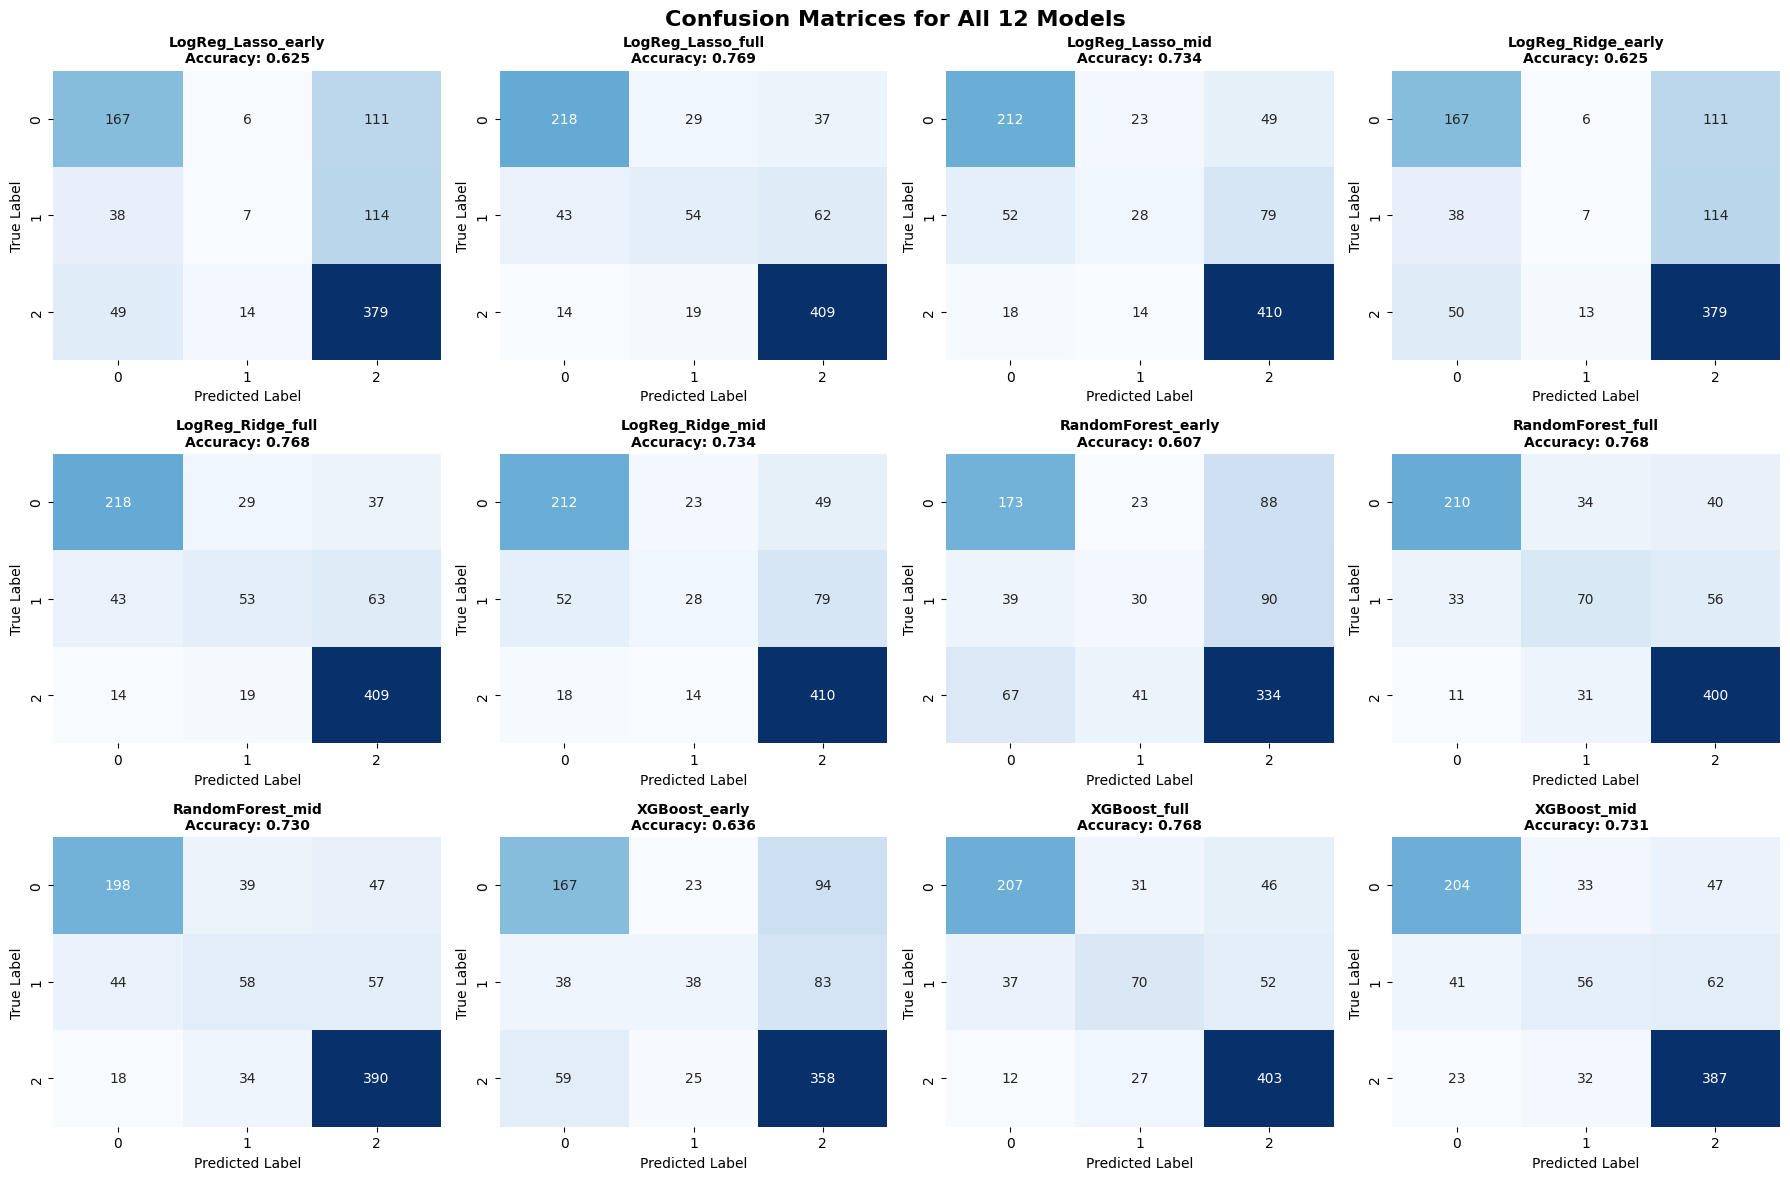

Confusion Matrices displayed!


In [ ]:
# Create confusion matrices for all models
n_models = len(models)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
fig.suptitle(f'Confusion Matrices for All {n_models} Models', fontsize=16, fontweight='bold')

model_names_sorted = sorted(models.keys())
axes_flat = axes.flatten()

for idx, model_name in enumerate(model_names_sorted):
    # Determine which dataset to use
    if 'LogReg' in model_name:
        dataset_name = model_name.split('_')[-1]
        X_test = datasets[dataset_name]['X_test']
        y_test_current = datasets[dataset_name]['y_test']
    else:
        dataset_name = model_name.split('_')[-1]
        X_test = datasets_unscaled[dataset_name]['X_test']
        y_test_current = datasets_unscaled[dataset_name]['y_test']
    
    model = models[model_name]
    y_pred = model.predict(X_test)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_current, y_pred, labels=model.classes_)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=model.classes_, yticklabels=model.classes_,
                cbar=False)
    axes_flat[idx].set_title(f'{model_name}\nAccuracy: {evaluation_results[model_name]["Accuracy"]:.3f}',
                            fontsize=10, fontweight='bold')
    axes_flat[idx].set_ylabel('True Label')
    axes_flat[idx].set_xlabel('Predicted Label')

# Hide extra subplots
for idx in range(len(model_names_sorted), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 12. Model Performance Summary and Comparison

In [25]:
# Create summary DataFrame
summary_data = []

for model_name in sorted(models.keys()):
    cv_result = cv_results.get(model_name, {'mean': 0, 'std': 0})
    eval_result = evaluation_results.get(model_name, {'F1': 0, 'Accuracy': 0, 'ROC-AUC': 0})
    
    # Extract algorithm and dataset
    if 'LogReg_Ridge' in model_name:
        algorithm = 'LogReg (Ridge)'
        dataset = model_name.split('_')[-1]
    elif 'LogReg_Lasso' in model_name:
        algorithm = 'LogReg (Lasso)'
        dataset = model_name.split('_')[-1]
    elif 'RandomForest' in model_name:
        algorithm = 'Random Forest'
        dataset = model_name.split('_')[-1]
    elif 'XGBoost' in model_name:
        algorithm = 'XGBoost'
        dataset = model_name.split('_')[-1]
    
    summary_data.append({
        'Model': model_name,
        'Algorithm': algorithm,
        'Dataset': dataset,
        'CV F1 (mean)': cv_result['mean'],
        'CV F1 (std)': cv_result['std'],
        'Test F1': eval_result['F1'],
        'Test Accuracy': eval_result['Accuracy'],
        'Test ROC-AUC': eval_result['ROC-AUC']
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*140)
print("MODEL PERFORMANCE SUMMARY")
print("="*140)
print(summary_df.to_string(index=False))
print("="*140)


MODEL PERFORMANCE SUMMARY
             Model      Algorithm Dataset  CV F1 (mean)  CV F1 (std)  Test F1  Test Accuracy  Test ROC-AUC
LogReg_Lasso_early LogReg (Lasso)   early      0.571076     0.010193 0.574669       0.624859      0.727985
 LogReg_Lasso_full LogReg (Lasso)    full      0.748669     0.012058 0.754676       0.769492      0.877699
  LogReg_Lasso_mid LogReg (Lasso)     mid      0.702706     0.009747 0.703204       0.734463      0.853632
LogReg_Ridge_early LogReg (Ridge)   early      0.573855     0.010813 0.574373       0.624859      0.727756
 LogReg_Ridge_full LogReg (Ridge)    full      0.748357     0.013842 0.753128       0.768362      0.877812
  LogReg_Ridge_mid LogReg (Ridge)     mid      0.702387     0.008880 0.703204       0.734463      0.853473
RandomForest_early  Random Forest   early      0.613427     0.007843 0.589533       0.606780      0.745122
 RandomForest_full  Random Forest    full      0.764852     0.010012 0.762030       0.768362      0.882072
  RandomFo

## Model Performance Analysis

In [ ]:
# Find best model
best_idx = summary_df['Test Accuracy'].idxmax()
best_model_row = summary_df.loc[best_idx]

print("\n" + "="*80)
print("BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model_row['Model']}")
print(f"Algorithm: {best_model_row['Algorithm']}")
print(f"Dataset: {best_model_row['Dataset']}")
print(f"Test Accuracy: {best_model_row['Test Accuracy']:.4f}")
print(f"Test F1 Score: {best_model_row['Test F1']:.4f}")
print(f"Test ROC-AUC: {best_model_row['Test ROC-AUC']:.4f}")
print("="*80)

# Analysis by Algorithm
print("\nAVERAGE PERFORMANCE BY ALGORITHM:")
print("-"*60)
algo_performance = summary_df.groupby('Algorithm')[['Test Accuracy', 'Test F1', 'Test ROC-AUC']].mean()
print(algo_performance.to_string())

# Analysis by Dataset
print("\nAVERAGE PERFORMANCE BY DATASET:")
print("-"*60)
dataset_performance = summary_df.groupby('Dataset')[['Test Accuracy', 'Test F1', 'Test ROC-AUC']].mean()
print(dataset_performance.to_string())

# Feature impact analysis
print("\n\nFEATURE IMPACT ANALYSIS:")
print("-"*60)
for algo in ['LogReg (Ridge)', 'LogReg (Lasso)', 'Random Forest', 'XGBoost']:
    algo_df = summary_df[summary_df['Algorithm'] == algo].sort_values('Dataset')
    dataset_order = ['early', 'mid', 'full']
    
    early_acc = algo_df[algo_df['Dataset'] == 'early']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'early']) > 0 else 0
    mid_acc = algo_df[algo_df['Dataset'] == 'mid']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'mid']) > 0 else 0
    full_acc = algo_df[algo_df['Dataset'] == 'full']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'full']) > 0 else 0
    
    sem1_impact = mid_acc - early_acc
    sem2_impact = full_acc - mid_acc
    total_impact = full_acc - early_acc
    
    print(f"\n{algo}:")
    print(f"  Early (baseline):          {early_acc:.4f}")
    print(f"  Mid (+1st semester):       {mid_acc:.4f} (improvement: {sem1_impact:+.4f})")
    print(f"  Full (+2nd semester):      {full_acc:.4f} (improvement: {sem2_impact:+.4f})")
    print(f"  Total feature impact:      {total_impact:+.4f}")


BEST PERFORMING MODEL
Model: LogReg_Lasso_full
Algorithm: LogReg (Lasso)
Dataset: full
Test Accuracy: 0.7695
Test F1 Score: 0.7547
Test ROC-AUC: 0.8777

AVERAGE PERFORMANCE BY ALGORITHM:
------------------------------------------------------------
                Test Accuracy   Test F1  Test ROC-AUC
Algorithm                                            
LogReg (Lasso)       0.709605  0.677516      0.819772
LogReg (Ridge)       0.709228  0.676902      0.819681
Random Forest        0.701695  0.691074      0.827217
XGBoost              0.711864  0.699681      0.837712


AVERAGE PERFORMANCE BY DATASET:
------------------------------------------------------------
         Test Accuracy   Test F1  Test ROC-AUC
Dataset                                       
early         0.623164  0.588977      0.739815
full          0.768644  0.757594      0.881815
mid           0.732486  0.712309      0.856656


FEATURE IMPACT ANALYSIS:
------------------------------------------------------------

LogReg (

## Visualization: Performance Comparison

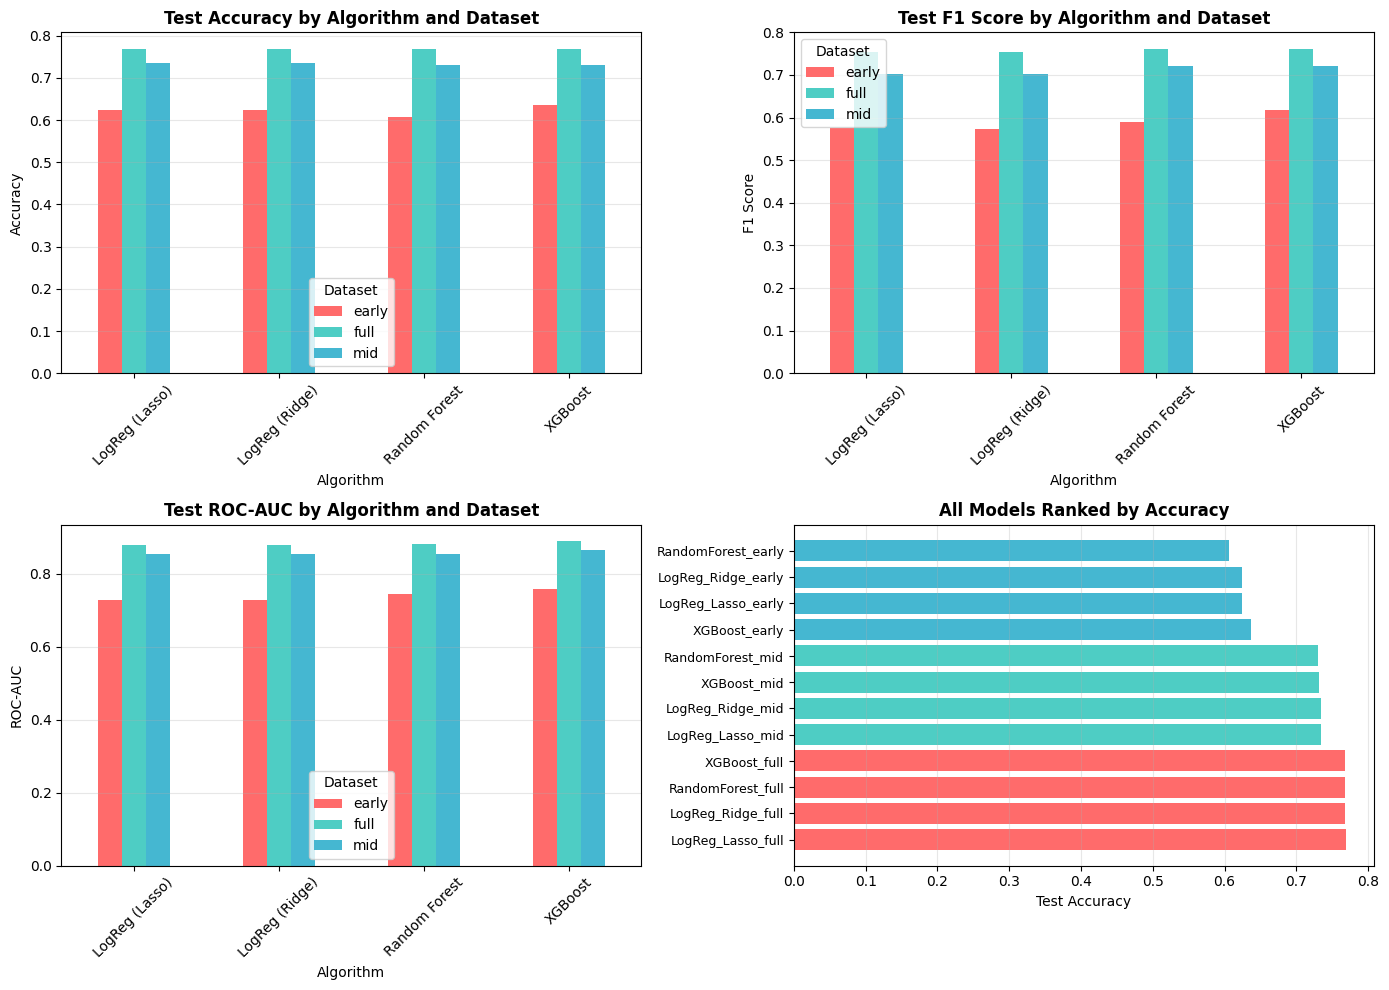

Performance comparison visualizations displayed!


In [28]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy by Algorithm and Dataset
pivot_accuracy = summary_df.pivot_table(values='Test Accuracy', index='Algorithm', columns='Dataset')
pivot_accuracy.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Test Accuracy by Algorithm and Dataset', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xlabel('Algorithm')
axes[0, 0].legend(title='Dataset')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. F1 Score by Algorithm and Dataset
pivot_f1 = summary_df.pivot_table(values='Test F1', index='Algorithm', columns='Dataset')
pivot_f1.plot(kind='bar', ax=axes[0, 1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_title('Test F1 Score by Algorithm and Dataset', fontweight='bold')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_xlabel('Algorithm')
axes[0, 1].legend(title='Dataset')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. ROC-AUC by Algorithm and Dataset
pivot_roc = summary_df.pivot_table(values='Test ROC-AUC', index='Algorithm', columns='Dataset')
pivot_roc.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_title('Test ROC-AUC by Algorithm and Dataset', fontweight='bold')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_xlabel('Algorithm')
axes[1, 0].legend(title='Dataset')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. All models - ranked by Accuracy
summary_sorted = summary_df.sort_values('Test Accuracy', ascending=False)
colors = ['#45B7D1' if 'early' in m else '#4ECDC4' if 'mid' in m else '#FF6B6B' for m in summary_sorted['Model']]
axes[1, 1].barh(range(len(summary_sorted)), summary_sorted['Test Accuracy'], color=colors)
axes[1, 1].set_yticks(range(len(summary_sorted)))
axes[1, 1].set_yticklabels(summary_sorted['Model'], fontsize=9)
axes[1, 1].set_xlabel('Test Accuracy')
axes[1, 1].set_title('All Models Ranked by Accuracy', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Performance comparison visualizations displayed!")

## Key Insights and Conclusions

#### 1. **Progressive Feature Sets**
- **df_early**: Baseline model using only demographic data available at enrollment
- **df_mid**: Adds early behavioral signal from 1st semester performance
- **df_full**: Complete picture with both semester performances

**Why this matters**: 
- Quantifies the value of collecting performance data
- Identifies optimal intervention timing
- Shows diminishing returns or critical tipping points

#### 2. **Three Algorithm Families**

**Multinomial Logistic Regression (Ridge/Lasso)**
- **Ridge**: Handles multicollinearity well, all features retained
- **Lasso**: Automatic feature selection, interpretable coefficients
- **Role**: Interpretable baseline and feature importance

**Random Forest**
- Captures non-linear relationships
- Robust to outliers
- No scaling required
- **Role**: Ensemble approach to improve upon linear baseline

**XGBoost**
- State-of-the-art gradient boosting
- Built-in regularization
- **Role**: Captures complex patterns for maximum performance

#### 3. **Validation Strategy**
- **5-Fold Cross-Validation**: Better estimate of generalization on training data
- **Stratified Split**: Maintains class distribution
- **Multiple Metrics**: F1 (handles class imbalance), Accuracy (overall performance), ROC-AUC (probabilistic ranking)

#### 4. **Expected Patterns**
- **df_early** should have lowest accuracy but fastest prediction capability
- **df_full** should have highest accuracy but requires waiting for semester data
- **Tree-based models** (RF, XGBoost) should outperform linear models due to feature interactions
- **XGBoost** typically achieves best performance due to gradient boosting
- The gap between df_early and df_mid shows the criticality of academic performance data